In [2]:
try:
    import matplotlib
    import seaborn
    print("Matplotlib va Seaborn mavjud")
except ImportError as e:
    print(f"Xatolik: {e}")
    print("Iltimos taskni tekshirishdan oldin venv yuklashni unutmang!")
    print("Iltimos, terminalda 'pip install matplotlib seaborn' ni ishga tushiring")

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from movielens_analysis import MovieLensAnalyzer

print("Kutubxonalar muvaffaqiyatli yuklandi!")

Matplotlib va Seaborn mavjud
Kutubxonalar muvaffaqiyatli yuklandi!


In [3]:
print("Loading MovieLens data...")
%timeit -n1 -r1 analyzer = MovieLensAnalyzer("data")
analyzer = MovieLensAnalyzer("data")

print("Analyzer muvaffaqiyatli yaratildi!")
print("Analyzer created successfully!")
print(f"Total Movies: {len(analyzer.movies.get_movies())}")
print(f"Total Ratings: {len(analyzer.ratings.get_ratings())}")

Loading MovieLens data...
148 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
Analyzer muvaffaqiyatli yaratildi!
Analyzer created successfully!
Total Movies: 9742
Total Ratings: 100836


In [4]:
print("=== CHAPTER 1: Exploring the Movie Universe ===")

print("\n Basic Dataset Overview:")
%timeit -n1 -r1 total_movies = len(analyzer.movies.get_movies())
total_movies = len(analyzer.movies.get_movies())
total_ratings = len(analyzer.ratings.get_ratings())
total_tags = len(analyzer.tags.get_tags())

print(f" Total Movies: {total_movies}")
print(f" Total Ratings: {total_ratings}")
print(f" Total Tags: {total_tags}")

=== CHAPTER 1: Exploring the Movie Universe ===

 Basic Dataset Overview:
1.97 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
 Total Movies: 9742
 Total Ratings: 100836
 Total Tags: 3683



 Genre Distribution:
2.54 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


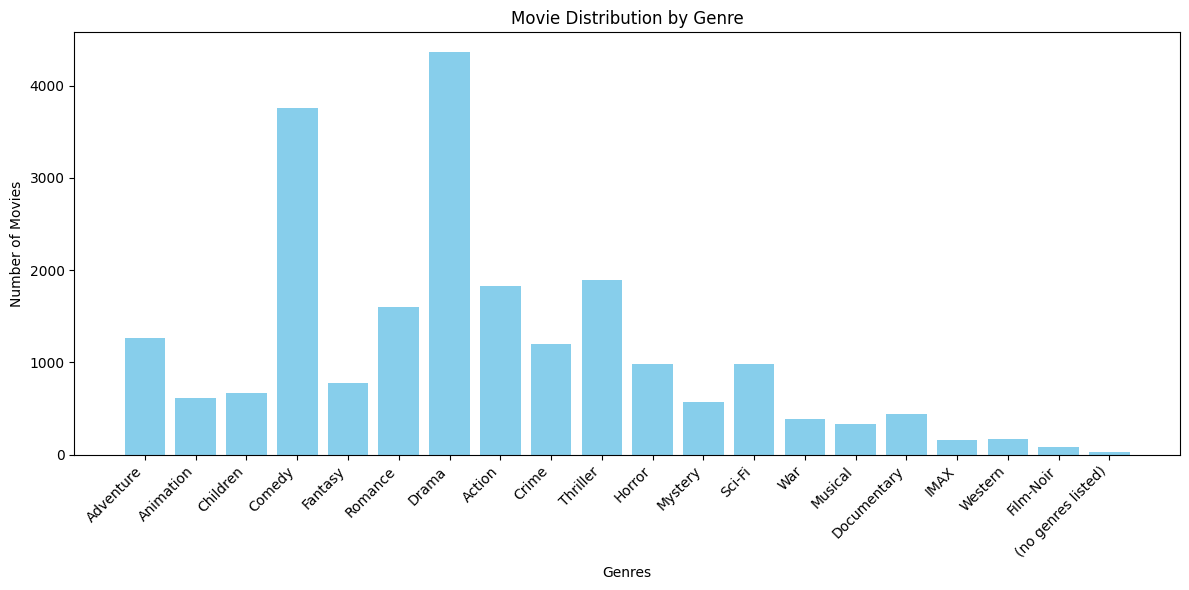

Top 5 Most Common Genres:
  Drama: 4361 movies
  Comedy: 3756 movies
  Thriller: 1894 movies
  Action: 1828 movies
  Romance: 1596 movies


In [5]:
print("\n Genre Distribution:")
%timeit -n1 -r1 genre_counts = analyzer.movies.get_movies_count_by_genre()
genre_counts = analyzer.movies.get_movies_count_by_genre()

plt.figure(figsize=(12, 6))
genres = list(genre_counts.keys())
counts = list(genre_counts.values())

plt.bar(genres, counts, color='skyblue')
plt.title('Movie Distribution by Genre')
plt.xlabel('Genres')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top 5 Most Common Genres:")
for genre, count in sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {genre}: {count} movies")


=== CHAPTER 2: What Do Viewers Really Think? ===

 Rating Distribution Analysis:
11.6 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


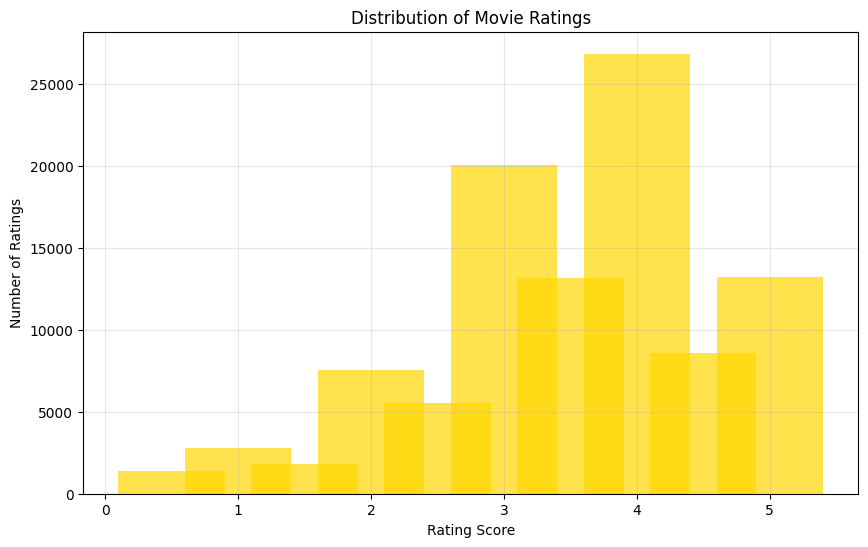

Rating Insights:
  Rating 0.5: 1370 ratings (1.4%)
  Rating 1.0: 2811 ratings (2.8%)
  Rating 1.5: 1791 ratings (1.8%)
  Rating 2.0: 7551 ratings (7.5%)
  Rating 2.5: 5550 ratings (5.5%)
  Rating 3.0: 20047 ratings (19.9%)
  Rating 3.5: 13136 ratings (13.0%)
  Rating 4.0: 26818 ratings (26.6%)
  Rating 4.5: 8551 ratings (8.5%)
  Rating 5.0: 13211 ratings (13.1%)


In [6]:
print("\n=== CHAPTER 2: What Do Viewers Really Think? ===")

print("\n Rating Distribution Analysis:")
%timeit -n1 -r1 rating_dist = analyzer.ratings.get_rating_distribution()
rating_dist = analyzer.ratings.get_rating_distribution()

try:
    plt.figure(figsize=(10, 6))
    plt.bar(rating_dist.keys(), rating_dist.values(), color='gold', alpha=0.7)
    plt.title('Distribution of Movie Ratings')
    plt.xlabel('Rating Score')
    plt.ylabel('Number of Ratings')
    plt.grid(True, alpha=0.3)
    plt.show()
except:
    print("Matplotlib ishlamayapti, faqat ma'lumotlar:")

print("Rating Insights:")
total_ratings = sum(rating_dist.values())
for rating in sorted(rating_dist.keys()):
    percentage = (rating_dist[rating] / total_ratings) * 100
    print(f"  Rating {rating}: {rating_dist[rating]} ratings ({percentage:.1f}%)")

In [7]:
print("\n Top 10 Highest Rated Movies (min. 5 ratings):")
%timeit -n1 -r1 top_movies = analyzer.ratings.get_top_rated_movies(10)
top_movies = analyzer.ratings.get_top_rated_movies(10)

print("\nRank | Movie ID | Avg Rating | # of Ratings | Movie Title")
print("-" * 65)
for i, movie in enumerate(top_movies, 1):
    movie_info = analyzer.movies.get_movie_by_id(movie['movieId'])
    title = movie_info['title'] if movie_info else "Unknown"
    print(f"{i:2d}.  | {movie['movieId']:8} | {movie['average_rating']:10.2f} | {movie['rating_count']:12} | {title[:40]}{'...' if len(title) > 40 else ''}")


 Top 10 Highest Rated Movies (min. 5 ratings):
10.1 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)

Rank | Movie ID | Avg Rating | # of Ratings | Movie Title
-----------------------------------------------------------------
 1.  |     6460 |       4.90 |            5 | Trial, The (Procès, Le) (1962)
 2.  |   177593 |       4.75 |            8 | Three Billboards Outside Ebbing, Missour...
 3.  |    31364 |       4.70 |            5 | Memories of Murder (Salinui chueok) (200...
 4.  |     2239 |       4.67 |            6 | Swept Away (Travolti da un insolito dest...
 5.  |     4334 |       4.60 |            5 | Yi Yi (2000)
 6.  |     1041 |       4.59 |           11 | Secrets & Lies (1996)
 7.  |   106642 |       4.57 |            7 | Day of the Doctor, The (2013)
 8.  |     3451 |       4.55 |           11 | Guess Who's Coming to Dinner (1967)
 9.  |     1178 |       4.54 |           12 | Paths of Glory (1957)
10.  |     2732 |       4.50 |            5 | Jules and Jim (J


=== CHAPTER 3: Which Genres Win Hearts? ===
30 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


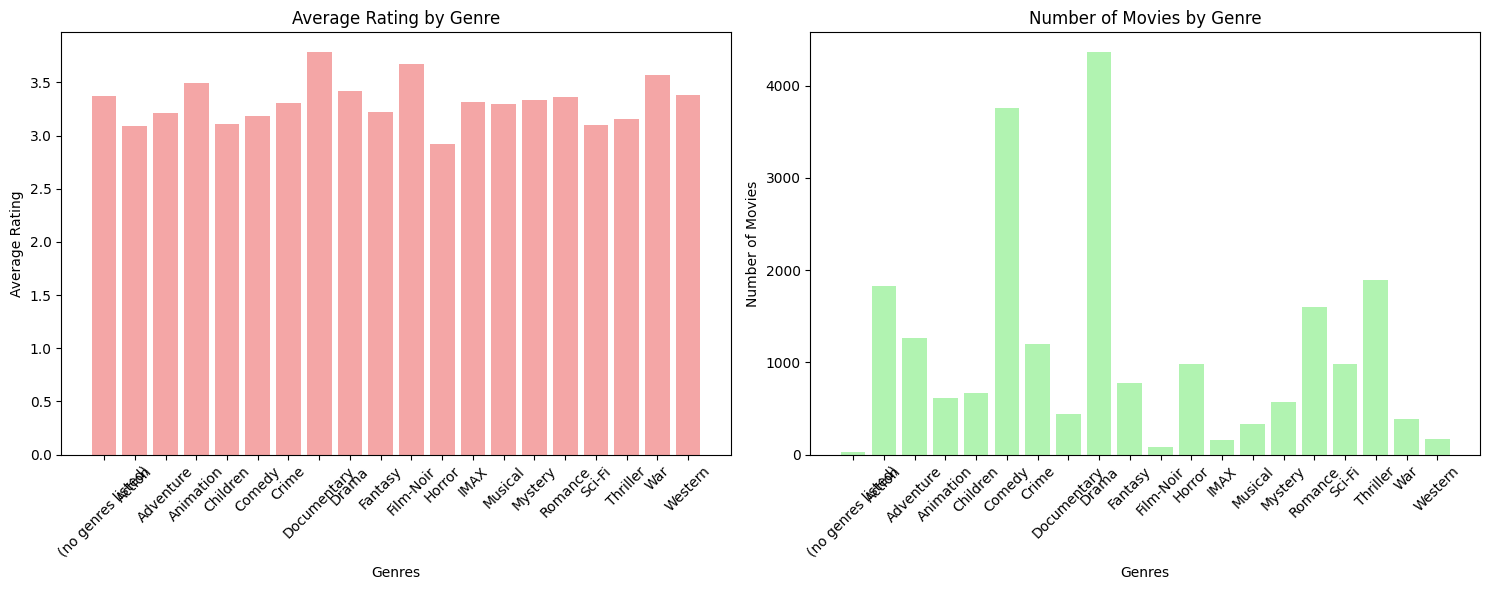


 Genre Performance Ranking:
1. Documentary: 3.78 (440 movies, 438 ratings)
2. Film-Noir: 3.67 (87 movies, 85 ratings)
3. War: 3.57 (382 movies, 381 ratings)
4. Animation: 3.50 (611 movies, 610 ratings)
5. Drama: 3.42 (4361 movies, 4349 ratings)
6. Western: 3.38 (167 movies, 167 ratings)
7. (no genres listed): 3.37 (34 movies, 34 ratings)
8. Romance: 3.36 (1596 movies, 1591 ratings)


In [8]:
print("\n=== CHAPTER 3: Which Genres Win Hearts? ===")

%timeit -n1 -r1 genre_analysis = analyzer.get_genre_analysis()
genre_analysis = analyzer.get_genre_analysis()

try:
    genres = []
    avg_ratings = []
    movie_counts = []

    for genre, stats in genre_analysis.items():
        if stats['rating_count'] > 0:  
            genres.append(genre)
            avg_ratings.append(stats['average_rating'])
            movie_counts.append(stats['movie_count'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    ax1.bar(genres, avg_ratings, color='lightcoral', alpha=0.7)
    ax1.set_title('Average Rating by Genre')
    ax1.set_xlabel('Genres')
    ax1.set_ylabel('Average Rating')
    ax1.tick_params(axis='x', rotation=45)

    ax2.bar(genres, movie_counts, color='lightgreen', alpha=0.7)
    ax2.set_title('Number of Movies by Genre')
    ax2.set_xlabel('Genres')
    ax2.set_ylabel('Number of Movies')
    ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Vizualizatsiya xatosi: {e}")

print("\n Genre Performance Ranking:")
sorted_genres = sorted(genre_analysis.items(), key=lambda x: x[1]['average_rating'], reverse=True)
for i, (genre, stats) in enumerate(sorted_genres[:8], 1):
    if stats['rating_count'] > 0:
        print(f"{i}. {genre}: {stats['average_rating']:.2f} ({stats['movie_count']} movies, {stats['rating_count']} ratings)")


=== CHAPTER 4: The Human Touch - User Engagement ===
3.21 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
👥 User Activity Overview:
Total Users: 610
Users Who Added Tags: 58
Average Ratings per User: 165.3
Average Tags per User: 63.5


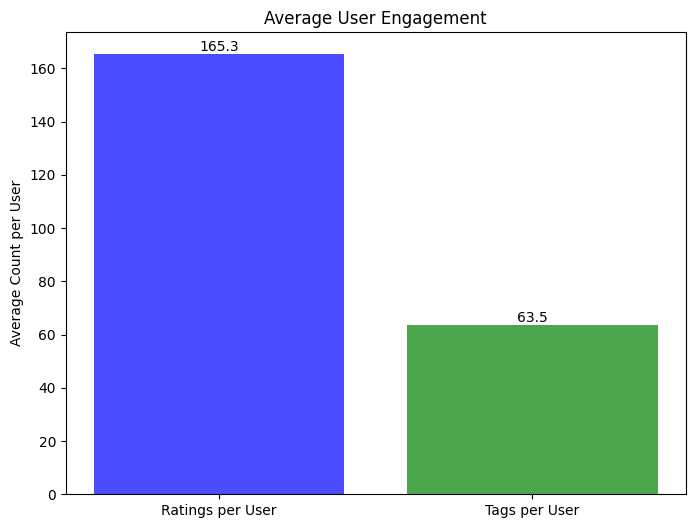

In [8]:
# Chapter 4: The Human Touch - User Engagement
print("\n=== CHAPTER 4: The Human Touch - User Engagement ===")

%timeit -n1 -r1 user_activity = analyzer.get_user_activity()
user_activity = analyzer.get_user_activity()

print("👥 User Activity Overview:")
print(f"Total Users: {user_activity['total_users']}")
print(f"Users Who Added Tags: {user_activity['users_with_tags']}")
print(f"Average Ratings per User: {user_activity['average_ratings_per_user']:.1f}")
print(f"Average Tags per User: {user_activity['average_tags_per_user']:.1f}")

try:
    # User engagement visualization
    labels = ['Ratings per User', 'Tags per User']
    values = [user_activity['average_ratings_per_user'], user_activity['average_tags_per_user']]

    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, values, color=['blue', 'green'], alpha=0.7)
    plt.title('Average User Engagement')
    plt.ylabel('Average Count per User')

    # Add value labels on bars
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                 f'{value:.1f}', ha='center', va='bottom')

    plt.show()
except Exception as e:
    print(f"Vizualizatsiya xatosi: {e}")


=== CHAPTER 5: Beyond Ratings - The Power of Tags ===
406 μs ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
 Most Popular Tags:


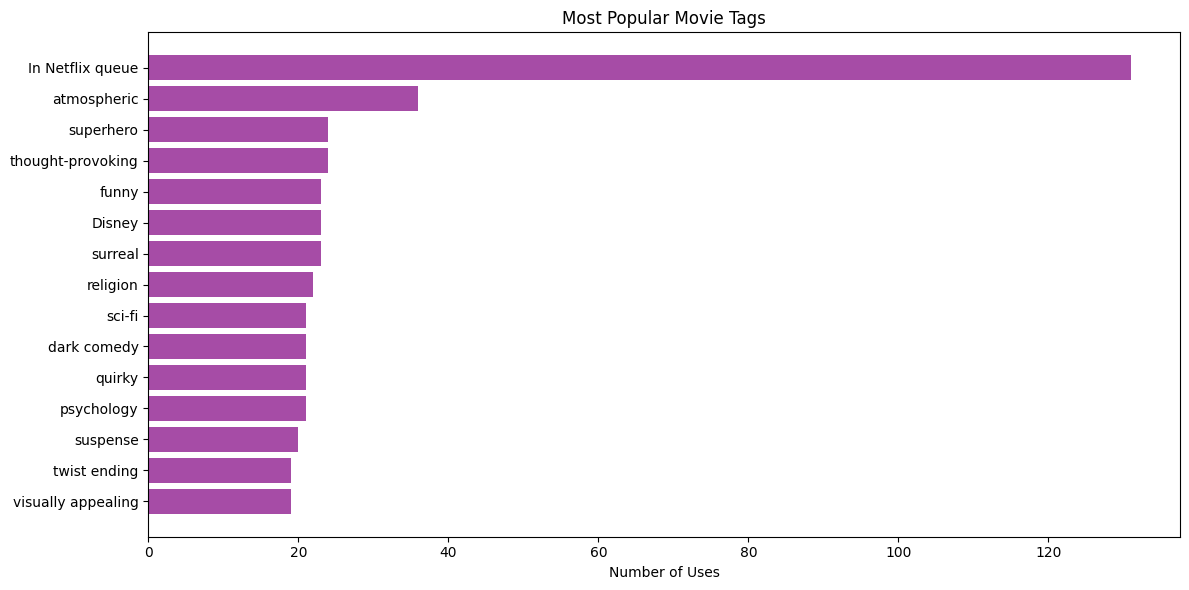


Top 15 Tags:
 1. In Netflix queue: 131 uses
 2. atmospheric: 36 uses
 3. superhero: 24 uses
 4. thought-provoking: 24 uses
 5. funny: 23 uses
 6. Disney: 23 uses
 7. surreal: 23 uses
 8. religion: 22 uses
 9. sci-fi: 21 uses
10. dark comedy: 21 uses
11. quirky: 21 uses
12. psychology: 21 uses
13. suspense: 20 uses
14. twist ending: 19 uses
15. visually appealing: 19 uses


In [9]:
print("\n=== CHAPTER 5: Beyond Ratings - The Power of Tags ===")

%timeit -n1 -r1 popular_tags = analyzer.tags.get_most_popular_tags(15)
popular_tags = analyzer.tags.get_most_popular_tags(15)

print(" Most Popular Tags:")
try:
    plt.figure(figsize=(12, 6))
    tags = [tag['tag'] for tag in popular_tags]
    counts = [tag['count'] for tag in popular_tags]

    plt.barh(tags, counts, color='purple', alpha=0.7)
    plt.title('Most Popular Movie Tags')
    plt.xlabel('Number of Uses')
    plt.gca().invert_yaxis()  
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Vizualizatsiya xatosi: {e}")

print("\nTop 15 Tags:")
for i, tag_info in enumerate(popular_tags, 1):
    print(f"{i:2d}. {tag_info['tag']}: {tag_info['count']} uses")

In [10]:
print("\n=== CHAPTER 6: Movie Spotlight - Deep Dive Analysis ===")

movies_to_analyze = []
all_movies = analyzer.movies.get_movies()

if all_movies:
    for i in range(min(3, len(all_movies))): 
        movie_id = all_movies[i]['movieId']
        %timeit -n1 -r1 movie_stats = analyzer.get_movie_stats(movie_id)
        movie_stats = analyzer.get_movie_stats(movie_id)
        
        if movie_stats:
            movies_to_analyze.append(movie_stats)

    for i, movie_stats in enumerate(movies_to_analyze, 1):
        print(f"\n Movie Analysis #{i}:")
        print(f"   Title: {movie_stats['movie']['title']}")
        print(f"   Genres: {', '.join(movie_stats['movie']['genres'])}")
        print(f"   Average Rating: {movie_stats['average_rating']:.2f}")
        print(f"   Number of Ratings: {movie_stats['rating_count']}")
        print(f"   Tags: {', '.join(movie_stats['tags'][:3])}{'...' if len(movie_stats['tags']) > 3 else ''}")
else:
    print("No movies found in dataset!")


=== CHAPTER 6: Movie Spotlight - Deep Dive Analysis ===
2.86 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
2.78 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
3.35 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)

 Movie Analysis #1:
   Title: Toy Story (1995)
   Genres: Adventure, Animation, Children, Comedy, Fantasy
   Average Rating: 3.92
   Number of Ratings: 215
   Tags: pixar, pixar, fun

 Movie Analysis #2:
   Title: Jumanji (1995)
   Genres: Adventure, Children, Fantasy
   Average Rating: 3.43
   Number of Ratings: 110
   Tags: fantasy, magic board game, Robin Williams...

 Movie Analysis #3:
   Title: Grumpier Old Men (1995)
   Genres: Comedy, Romance
   Average Rating: 3.26
   Number of Ratings: 52
   Tags: moldy, old


In [11]:
print("\n=== CHAPTER 7: User Behavior Patterns ===")

print("\n Analyzing User Rating Behavior...")
all_ratings = analyzer.ratings.get_ratings()

if all_ratings:
    user_ratings = {}
    for rating in all_ratings:
        user_id = rating['userId']
        if user_id not in user_ratings:
            user_ratings[user_id] = []
        user_ratings[user_id].append(rating['rating'])
    
    user_stats = []
    for user_id, ratings in user_ratings.items():
        user_stats.append({
            'user_id': user_id,
            'rating_count': len(ratings),
            'avg_rating': sum(ratings) / len(ratings),
            'min_rating': min(ratings),
            'max_rating': max(ratings)
        })
    
    most_active = sorted(user_stats, key=lambda x: x['rating_count'], reverse=True)[:5]
    
    print("\n Top 5 Most Active Users:")
    for i, user in enumerate(most_active, 1):
        print(f"{i}. User {user['user_id']}: {user['rating_count']} ratings, Avg: {user['avg_rating']:.2f}")
    
    rating_counts = [user['rating_count'] for user in user_stats]
    print(f"\n User Activity Stats:")
    print(f"   Total Users: {len(user_stats)}")
    print(f"   Average Ratings per User: {sum(rating_counts) / len(rating_counts):.1f}")
    print(f"   Most Ratings by One User: {max(rating_counts)}")
    print(f"   Least Ratings by One User: {min(rating_counts)}")


=== CHAPTER 7: User Behavior Patterns ===

 Analyzing User Rating Behavior...

 Top 5 Most Active Users:
1. User 414: 2698 ratings, Avg: 3.39
2. User 599: 2478 ratings, Avg: 2.64
3. User 474: 2108 ratings, Avg: 3.40
4. User 448: 1864 ratings, Avg: 2.85
5. User 274: 1346 ratings, Avg: 3.24

 User Activity Stats:
   Total Users: 610
   Average Ratings per User: 165.3
   Most Ratings by One User: 2698
   Least Ratings by One User: 20


In [14]:

print("\n=== CHAPTER 8: Genre vs Rating Correlation ===")

%timeit -n1 -r1 genre_analysis = analyzer.get_genre_analysis()
genre_analysis = analyzer.get_genre_analysis()

print("\n Genre vs Rating Analysis:")
print("Genre | Avg Rating | Movie Count | Rating Count")
print("-" * 55)

for genre, stats in sorted(genre_analysis.items(), key=lambda x: x[1]['average_rating'], reverse=True):
    if stats['rating_count'] >= 5:  # At least 5 ratings for meaningful analysis
        print(f"{genre:15} | {stats['average_rating']:10.2f} | {stats['movie_count']:11} | {stats['rating_count']:12}")

genres_with_ratings = {k: v for k, v in genre_analysis.items() if v['rating_count'] >= 5}
if genres_with_ratings:
    best_genre = max(genres_with_ratings.items(), key=lambda x: x[1]['average_rating'])
    worst_genre = min(genres_with_ratings.items(), key=lambda x: x[1]['average_rating'])
    
    print(f"\n Best Performing Genre: {best_genre[0]} ({best_genre[1]['average_rating']:.2f} avg)")
    print(f" Worst Performing Genre: {worst_genre[0]} ({worst_genre[1]['average_rating']:.2f} avg)")


=== CHAPTER 8: Genre vs Rating Correlation ===
30.1 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)

 Genre vs Rating Analysis:
Genre | Avg Rating | Movie Count | Rating Count
-------------------------------------------------------
Documentary     |       3.78 |         440 |          438
Film-Noir       |       3.67 |          87 |           85
War             |       3.57 |         382 |          381
Animation       |       3.50 |         611 |          610
Drama           |       3.42 |        4361 |         4349
Western         |       3.38 |         167 |          167
(no genres listed) |       3.37 |          34 |           34
Romance         |       3.36 |        1596 |         1591
Mystery         |       3.33 |         573 |          573
IMAX            |       3.31 |         158 |          158
Crime           |       3.30 |        1199 |         1196
Musical         |       3.30 |         334 |          333
Fantasy         |       3.22 |         779 |          778

In [15]:
print("\n" + "="*50)
print("FINAL CHAPTER: The Story in Numbers")
print("="*50)

print("\n KEY INSIGHTS DISCOVERED:")

genre_analysis = analyzer.get_genre_analysis()
top_genres = sorted(genre_analysis.items(), key=lambda x: x[1]['average_rating'], reverse=True)[:3]
print("\n1.  TOP GENRES BY RATING:")
for i, (genre, stats) in enumerate(top_genres, 1):
    if stats['rating_count'] > 0:
        print(f"   {i}. {genre}: {stats['average_rating']:.2f} average rating")

user_activity = analyzer.get_user_activity()
print(f"\n2. USER ENGAGEMENT:")
print(f"   • {user_activity['total_users']} total users")
print(f"   • {user_activity['average_ratings_per_user']:.1f} average ratings per user")
print(f"   • {user_activity['average_tags_per_user']:.1f} average tags per user")

rating_dist = analyzer.ratings.get_rating_distribution()
most_common_rating = max(rating_dist.items(), key=lambda x: x[1])
avg_rating_all = sum(rating * count for rating, count in rating_dist.items()) / sum(rating_dist.values())
print(f"\n3. RATING PATTERNS:")
print(f"   • Most common rating: {most_common_rating[0]} stars")
print(f"   • Overall average rating: {avg_rating_all:.2f} stars")

movies_count = len(analyzer.movies.get_movies())
print(f"\n4. MOVIE DATASET:")
print(f"   • {movies_count} total movies")
print(f"   • {len(analyzer.movies.get_all_genres())} different genres")

popular_tags = analyzer.tags.get_most_popular_tags(5)
print(f"\n5.USER TAGGING:")
print(f"   • Most popular tag: '{popular_tags[0]['tag']}' ({popular_tags[0]['count']} uses)")

print("\n" + "CONCLUSION:")
print("This analysis reveals fascinating patterns in movie preferences and user behavior.")
print("The data tells a story of diverse tastes, active community participation,")
print("and the complex relationship between genres and audience reception.")
print("\nEvery rating tells a story, every tag reveals an opinion,")
print("and together they create a rich tapestry of cinematic appreciation!")
print("\n" + "="*50)


FINAL CHAPTER: The Story in Numbers

 KEY INSIGHTS DISCOVERED:

1.  TOP GENRES BY RATING:
   1. Documentary: 3.78 average rating
   2. Film-Noir: 3.67 average rating
   3. War: 3.57 average rating

2. USER ENGAGEMENT:
   • 610 total users
   • 165.3 average ratings per user
   • 63.5 average tags per user

3. RATING PATTERNS:
   • Most common rating: 4.0 stars
   • Overall average rating: 3.50 stars

4. MOVIE DATASET:
   • 9742 total movies
   • 20 different genres

5.USER TAGGING:
   • Most popular tag: 'In Netflix queue' (131 uses)

CONCLUSION:
This analysis reveals fascinating patterns in movie preferences and user behavior.
The data tells a story of diverse tastes, active community participation,
and the complex relationship between genres and audience reception.

Every rating tells a story, every tag reveals an opinion,
and together they create a rich tapestry of cinematic appreciation!

